In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import random
import cv2
from tqdm.notebook import tqdm

In [ ]:
#dataset z kaggle
import kagglehub
path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lgg-mri-segmentation' dataset.
Path to dataset files: /kaggle/input/lgg-mri-segmentation


In [ ]:
#segregacja danych
pliki = glob.glob(path + "/kaggle_3m" + '/**/*.tif', recursive=True)
masks_paths = [f for f in pliki if "mask" in f]
images_paths = [f for f in pliki if "mask" not in f]
df_masks = pd.DataFrame({'mask_path': masks_paths})
df_images = pd.DataFrame({'image_path': images_paths})
df_images['id'] = df_images['image_path'].str.replace('.tif', '', regex=False)
df_masks['id'] = df_masks['mask_path'].str.replace('_mask.tif', '', regex=False)
df = pd.merge(df_images, df_masks, on='id')
df = df.drop(columns=['id'])

Liczba obrazów: 3929
Liczba masek: 3929
Obraz: /kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_5849_19950405/TCGA_DU_5849_19950405_25.tif
Maska: /kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_5849_19950405/TCGA_DU_5849_19950405_25_mask.tif


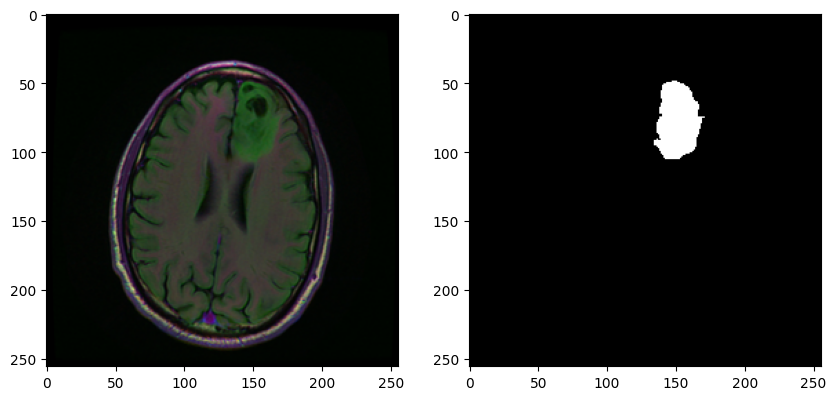

In [ ]:
#test wczytania danych
print(f"Liczba obrazów: {len(df_images)}")
print(f"Liczba masek: {len(df_masks)}")
test = random.randint(0, len(df) - 1)
print("Obraz:", df.iloc[test]['image_path'])
print("Maska:", df.iloc[test]['mask_path'])
img = cv2.imread(df.iloc[test]['image_path'])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
msk = cv2.imread(df.iloc[test]['mask_path'])
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.subplot(1, 2, 2)
plt.imshow(msk)
plt.show()

In [ ]:
#podział zbioru
from sklearn.model_selection import train_test_split
train_val, test_df = train_test_split(df, test_size=0.15, random_state=42)
train_df, val_df = train_test_split(train_val, test_size=0.15, random_state=42)

print(f"Liczba zdjęć do treningu: {len(train_df)}")
print(f"Liczba zdjęć do walidacji: {len(val_df)}")
print(f"Liczba zdjęć do testu: {len(test_df)}")

Liczba zdjęć do treningu: 2838
Liczba zdjęć do walidacji: 501
Liczba zdjęć do testu: 590


In [ ]:
#tworzenie datasetu
from torch.utils.data import Dataset
class BrainMRIDataset(Dataset):
  def __init__(self, df, transforms = None):
    self.df = df
    self.transforms = transforms

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    mask_pth = self.df.mask_path.iloc[idx]
    image_pth = self.df.image_path.iloc[idx]
    mask = cv2.imread(mask_pth, cv2.IMREAD_GRAYSCALE)
    image = cv2.imread(image_pth)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mask = mask.astype(np.float32)/255.0
    image = image.astype(np.float32)/255.0
    #(H, W, C) -> (C, H, W)
    image = np.transpose(image, (2, 0, 1))
    #(H, W) -> (1, H, W)
    mask = np.expand_dims(mask, axis=0)
    return torch.from_numpy(image), torch.from_numpy(mask)

In [ ]:
#test
train_ds = BrainMRIDataset(train_df)
img, msk = train_ds[0]
print(f"Obraz shape: {img.shape}") # Powinno być [3, 256, 256]
print(f"Maska shape: {msk.shape}") # Powinno być [1, 256, 256]
print(f"Max obrazu: {img.max()}") # Powinno być <= 1.0
print(f"Max maski: {msk.max()}") # Powinno być 1.0 (jeśli jest tam guz) lub 0.0

Obraz shape: torch.Size([3, 256, 256])
Maska shape: torch.Size([1, 256, 256])
Max obrazu: 0.43529412150382996
Max maski: 0.0


In [ ]:
#dataloader
train_ds = BrainMRIDataset(train_df)
val_ds= BrainMRIDataset(val_df)
test_ds = BrainMRIDataset(test_df)
from torch.utils.data import DataLoader
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)



In [ ]:
#korzystamy z archietktury modelu u-net
from torch import nn
class doubleConvolution(nn.Module):
  def __init__(self, in_channels, out_channels):
    super(doubleConvolution, self).__init__()
    self.conv = nn.Sequential(
    nn.Conv2d(in_channels,out_channels,kernel_size=3,padding=1),
    nn.BatchNorm2d(out_channels),
    nn.ReLU(inplace = True),
    nn.Conv2d(out_channels,out_channels,kernel_size=3,padding=1),
    nn.BatchNorm2d(out_channels),
    nn.ReLU(inplace = True)
    )
  def forward(self,x):
    return self.conv(x)
class Unet(nn.Module):
  def __init__(self,in_channels,out_channels):
    super(Unet,self).__init__()
    self.enc1 = doubleConvolution(in_channels,64)
    self.pool1 = nn.MaxPool2d(kernel_size=2,stride=2)
    self.enc2 = doubleConvolution(64,128)
    self.pool2 = nn.MaxPool2d(kernel_size=2,stride=2)
    self.enc3 = doubleConvolution(128,256)
    self.pool3 = nn.MaxPool2d(kernel_size=2,stride=2)
    self.enc4 = doubleConvolution(256,512)
    self.pool4 = nn.MaxPool2d(kernel_size=2,stride=2)
    self.bottleneck = doubleConvolution(512,1024)
    self.up1 = nn.ConvTranspose2d(1024,512,kernel_size=2,stride=2)
    self.dec1 = doubleConvolution(1024,512)
    self.up2 = nn.ConvTranspose2d(512,256,kernel_size=2,stride=2)
    self.dec2 = doubleConvolution(512,256)
    self.up3 = nn.ConvTranspose2d(256,128,kernel_size=2,stride=2)
    self.dec3 = doubleConvolution(256,128)
    self.up4 = nn.ConvTranspose2d(128,64,kernel_size=2,stride=2)
    self.dec4 = doubleConvolution(128,64)
    self.final_conv = nn.Conv2d(64,out_channels,kernel_size=1)

  def forward(self,x):
    s1 = self.enc1(x)
    p1 = self.pool1(s1)
    s2 = self.enc2(p1)
    p2 = self.pool2(s2)
    s3 = self.enc3(p2)
    p3 = self.pool3(s3)
    s4 = self.enc4(p3)
    p4 = self.pool4(s4)

    b = self.bottleneck(p4)

    u1 = self.up1(b)
    merge1 =torch.cat([s4,u1],dim=1)
    d1 = self.dec1(merge1)
    u2 = self.up2(d1)
    merge2 = torch.cat([s3,u2],dim=1)
    d2 = self.dec2(merge2)
    u3 = self.up3(d2)
    merge3 = torch.cat([s2,u3],dim=1)
    d3 = self.dec3(merge3)
    u4 = self.up4(d3)
    merge4 = torch.cat([s1,u4],dim=1)
    d4 = self.dec4(merge4)

    return self.final_conv(d4)



In [ ]:
#tworzenie loss function - dice loss
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, predict, target):
        target = target.float()
        predict = torch.sigmoid(predict)
        predict = torch.flatten(predict)
        target = torch.flatten(target)
        intersection = torch.sum(predict * target)
        dice = (2.0 *intersection + self.smooth) / (torch.sum(predict) + torch.sum(target) + self.smooth)
        return 1 - dice

In [ ]:
from tqdm.notebook import tqdm

# Parametry i inicjalizacja
EPOCHS = 2
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Unet(in_channels=3, out_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

criterion_dice = DiceLoss()
criterion_BCE = nn.BCEWithLogitsLoss()

train_loss_history = []
val_loss_history = []

print(f"Rozpoczynam trening na urządzeniu: {device}")

for epoch in range(EPOCHS):
    model.train()
    train_running_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", unit="batch")

    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss_dice = criterion_dice(outputs, masks)
        loss_BCE = criterion_BCE(outputs, masks.float())
        total_loss = loss_dice + loss_BCE

        total_loss.backward()
        optimizer.step()

        train_running_loss += total_loss.item()

        pbar.set_postfix({'loss': total_loss.item()})

    epoch_train_loss = train_running_loss / len(train_loader)
    train_loss_history.append(epoch_train_loss)

    model.eval()
    val_running_loss = 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss_dice = criterion_dice(outputs, masks)
            loss_BCE = criterion_BCE(outputs, masks.float())
            total_loss = loss_dice + loss_BCE

            val_running_loss += total_loss.item()

    epoch_val_loss = val_running_loss / len(val_loader)
    val_loss_history.append(epoch_val_loss)

    print(f"Summary Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
    print("-" * 30)

print("Trening zakończony!")

Rozpoczynam trening na urządzeniu: cuda


Epoch 1/2 [Train]:   0%|          | 0/178 [00:00<?, ?batch/s]

Summary Epoch 1 | Train Loss: 1.4291 | Val Loss: 1.3202
------------------------------


Epoch 2/2 [Train]:   0%|          | 0/178 [00:00<?, ?batch/s]

Summary Epoch 2 | Train Loss: 1.2655 | Val Loss: 1.2137
------------------------------
Trening zakończony!


In [ ]:
#zapis modelu
torch.save(model.state_dict(), 'unet_brain_mri.pth')
print("Model zapisany pomyślnie")

Model zapisany pomyślnie!


In [ ]:
#wczytywanie
model = Unet(in_channels=3, out_channels=1).to(device)
model.load_state_dict(torch.load('unet_brain_mri.pth', map_location=device))
model.eval()
print("Model wczytany")

Model wczytany i gotowy do pracy!


In [ ]:
def calculate_iou(pred_mask, true_mask):
    pred_mask = pred_mask.view(-1)
    true_mask = true_mask.view(-1)

    intersection = (pred_mask * true_mask).sum()
    union = pred_mask.sum() + true_mask.sum() - intersection

    if union == 0:
        return 1.0 if intersection == 0 else 0.0
    else:
        return (intersection / union).item()

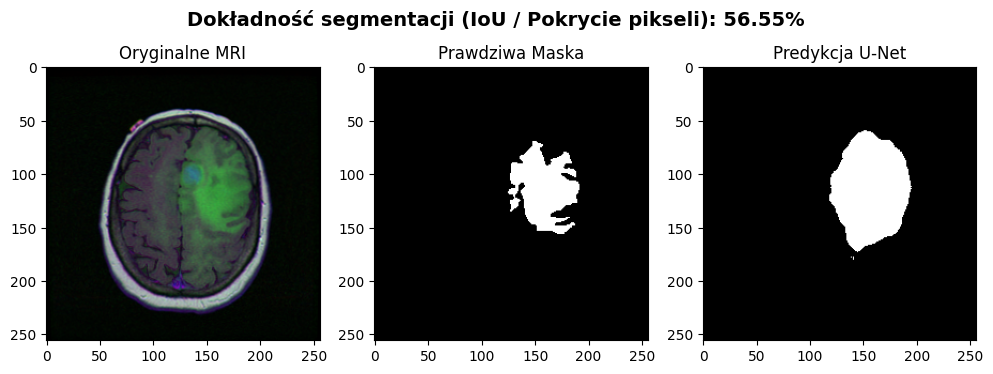

In [ ]:
model.eval()
with torch.no_grad():
    img, real_mask = test_ds[random.randint(0, len(test_ds)-1)]

    input_img = img.unsqueeze(0).to(device)
    real_mask_device = real_mask.to(device)


    output = model(input_img)
    output = torch.sigmoid(output)
    output = (output > 0.5).float()

    iou_score = calculate_iou(output, real_mask_device)
    pixel_coverage_percentage = iou_score * 100

    plt.figure(figsize=(12, 4))

    plt.suptitle(f"Dokładność segmentacji (IoU / Pokrycie pikseli): {pixel_coverage_percentage:.2f}%", fontsize=14, fontweight='bold')

    plt.subplot(1, 3, 1)
    plt.title("Oryginalne MRI")
    plt.imshow(img.permute(1, 2, 0))

    plt.subplot(1, 3, 2)
    plt.title("Prawdziwa Maska")
    plt.imshow(real_mask.squeeze(), cmap='gray')

    plt.subplot(1, 3, 3)
    plt.title("Predykcja U-Net")
    plt.imshow(output.cpu().squeeze(), cmap='gray')

    plt.show()